In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from kneefinder import KneeFinder
from kneed import KneeLocator

In [2]:
df = pd.read_csv('../../results/uc_vs_hc/pathway_meta_all.csv')

In [3]:
df['abs_combined_nes'] = df['combined_nes'].abs()
df = df[(df['abs_combined_nes'] > 1) & (df['q_value'] < 0.05)]
sorted_nes = df['abs_combined_nes'].sort_values(ascending=False)

In [7]:
sorted_nes.iloc[-1]

1.0049790594443089

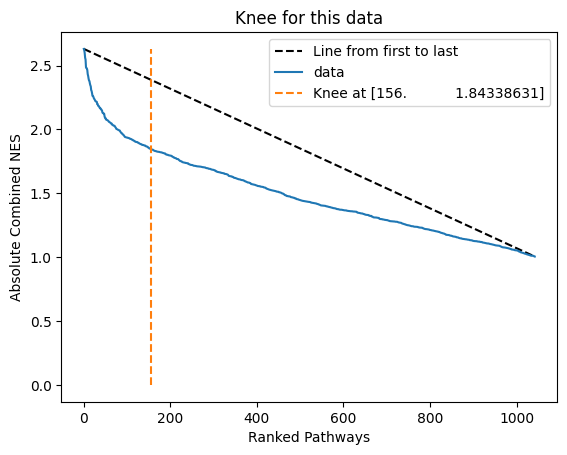

In [14]:
kf = KneeFinder(range(len(sorted_nes)), sorted_nes)

knee_x, knee_y = kf.find_knee()

plt.plot([0, len(sorted_nes)-1], [sorted_nes.iloc[0], sorted_nes.iloc[-1]], 'k--', label='Line from first to last')
plt.title("Knee Point Detection")
plt.xlabel("Ranked Pathways")
plt.ylabel("Absolute Combined NES")
kf.plot()
plt.show();

In [15]:
df_filtered = df[df['abs_combined_nes'] >= knee_y]
# df_filtered = df

df_filtered.to_csv('../../results/uc_vs_hc/pathway_meta_significant_knee.csv', index=False)

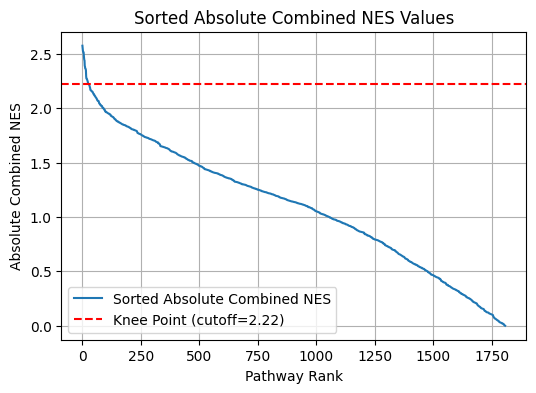

In [6]:
# use kneed to find the knee point with a specific sensitivity
kl = KneeLocator(range(len(sorted_nes)), sorted_nes, curve='convex', direction='decreasing')
cutoff = sorted_nes.iloc[kl.knee]

# plot the sorted NES values and the knee point
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(range(len(sorted_nes)), sorted_nes, label='Sorted Absolute Combined NES')
plt.axhline(cutoff, color='red', linestyle='--', label=f'Knee Point (cutoff={cutoff:.2f})')
plt.title('Sorted Absolute Combined NES Values')
plt.xlabel('Pathway Rank')
plt.ylabel('Absolute Combined NES')
plt.legend()
plt.grid()
plt.show();

In [33]:
df_filtered = df[df['abs_combined_nes'] >= cutoff]

df_filtered.to_csv('../../results/uc_vs_hc/pathway_meta_significant_knee.csv', index=False)

[79, 398, 603, 1107, 9141, 9141, 9141]
[0.01, 0.04, 0.06, 0.11, 0.92, 0.92, 0.92]


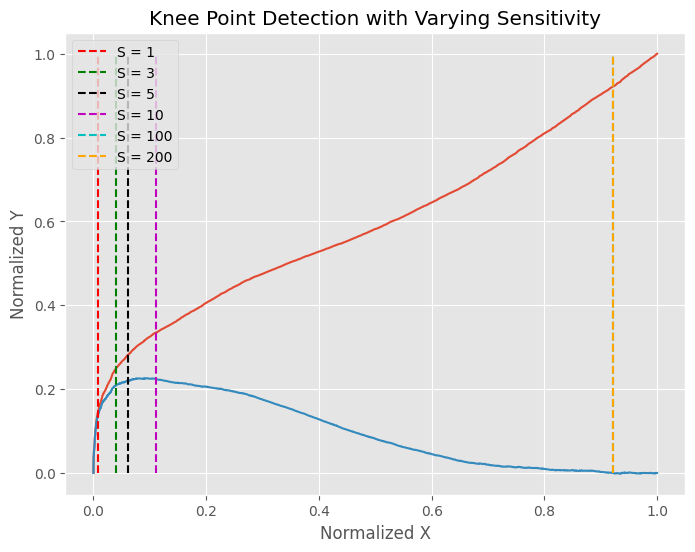

In [35]:
import numpy as np

sensitivity = [1, 3, 5, 10, 100, 200, 400]
knees = []
norm_knees = []

for s in sensitivity:
    kl = KneeLocator(range(len(sorted_nes)), sorted_nes, curve='convex', direction='decreasing', S=s)
    knees.append(kl.knee)
    norm_knees.append(kl.norm_knee)

print(knees)
[43, 137, 178, 258, 305, 482, 482]

print([nk.round(2) for nk in norm_knees])
[0.04, 0.14, 0.18, 0.26, 0.3, 0.48, 0.48]

import matplotlib.pyplot as plt

plt.style.use("ggplot")
plt.figure(figsize=(8, 6))
plt.plot(kl.x_normalized, kl.y_normalized)
plt.plot(kl.x_difference, kl.y_difference)
colors = ["r", "g", "k", "m", "c", "orange"]
for k, c, s in zip(norm_knees, colors, sensitivity):
    plt.vlines(k, 0, 1, linestyles="--", colors=c, label=f"S = {s}")
plt.legend()
plt.title("Knee Point Detection with Varying Sensitivity")
plt.xlabel("Normalized X")
plt.ylabel("Normalized Y")
plt.show();